# LPC Spritesheet Preprocessing Pipeline

Extracts 64×64 RGBA frames from raw spritesheets and saves them to `dataset/processed/{category}/`.
Fully-transparent frames are discarded. Already-saved frames are skipped on re-run.

In [19]:
import os
import time
import multiprocessing as mp
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from PIL import Image

SPRITESHEETS = Path('dataset/spritesheets')
PROCESSED    = Path('dataset/processed')
FRAME_SIZE   = 64
NUM_WORKERS  = max(1, mp.cpu_count() - 1)

print(f'CPU workers : {NUM_WORKERS}')
print(f'Spritesheets: {SPRITESHEETS.resolve()}')
print(f'Processed   : {PROCESSED.resolve()}')

CPU workers : 7
Spritesheets: /Users/gomuseo/Desktop/Python/vae_test/dataset/spritesheets
Processed   : /Users/gomuseo/Desktop/Python/vae_test/dataset/processed


---
## 1. Before — Raw Spritesheet Overview

In [20]:
# Count sheets per category
cat_sheet_counts = Counter()
all_sheets = sorted(SPRITESHEETS.rglob('*.png'))
for p in all_sheets:
    cat_sheet_counts[p.relative_to(SPRITESHEETS).parts[0]] += 1

total_sheets = sum(cat_sheet_counts.values())
print(f'Total spritesheet files : {total_sheets:,}')
print(f'Categories              : {len(cat_sheet_counts)}')

Total spritesheet files : 144,699
Categories              : 21


In [21]:
# Spritesheet size distribution (sample 3000)
size_counter = Counter()
for i, p in enumerate(all_sheets):
    if i >= 3000:
        break
    try:
        img = Image.open(p)
        size_counter[img.size] += 1
    except Exception:
        pass

top_sizes = size_counter.most_common(10)
print('Top 10 spritesheet sizes (w×h)  →  frames per sheet')
for (w, h), cnt in top_sizes:
    print(f'  {w:4d}×{h:3d}  ({w//64}×{h//64} frames)  —  {cnt} sheets')

Top 10 spritesheet sizes (w×h)  →  frames per sheet
   384×256  (6×4 frames)  —  446 sheets
   832×256  (13×4 frames)  —  443 sheets
   512×256  (8×4 frames)  —  421 sheets
   384× 64  (6×1 frames)  —  395 sheets
   448×256  (7×4 frames)  —  294 sheets
   576×256  (9×4 frames)  —  294 sheets
   192×256  (3×4 frames)  —  293 sheets
   128×256  (2×4 frames)  —  283 sheets
   320×256  (5×4 frames)  —  131 sheets


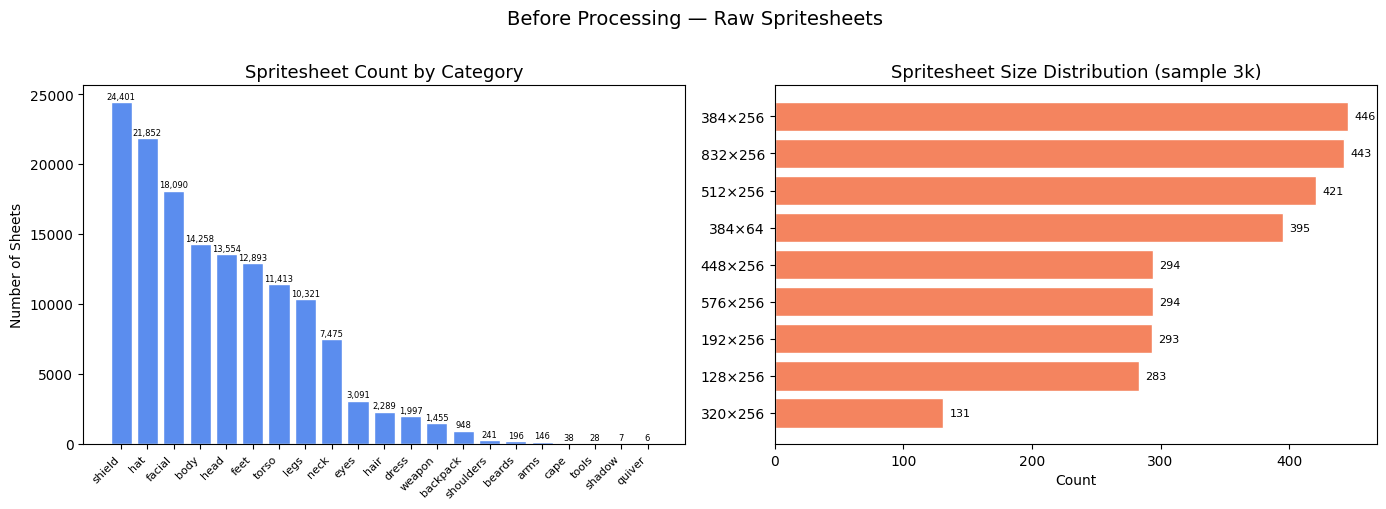

In [22]:
# --- Figure 1: sheets per category (bar) + size distribution (bar) ---
cats_s, cnts_s = zip(*cat_sheet_counts.most_common())
sizes_lbl  = [f'{w}×{h}' for (w, h), _ in top_sizes]
sizes_cnt  = [c for _, c in top_sizes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# left: sheets per category
bars1 = ax1.bar(cats_s, cnts_s, color='#5b8dee', edgecolor='white')
ax1.set_title('Spritesheet Count by Category', fontsize=13)
ax1.set_ylabel('Number of Sheets')
ax1.set_xticks(range(len(cats_s)))
ax1.set_xticklabels(cats_s, rotation=45, ha='right', fontsize=8)
for bar, v in zip(bars1, cnts_s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{v:,}', ha='center', va='bottom', fontsize=6)

# right: size distribution
bars2 = ax2.barh(sizes_lbl[::-1], sizes_cnt[::-1], color='#f4845f', edgecolor='white')
ax2.set_title('Spritesheet Size Distribution (sample 3k)', fontsize=13)
ax2.set_xlabel('Count')
for bar, v in zip(bars2, sizes_cnt[::-1]):
    ax2.text(v + 5, bar.get_y() + bar.get_height()/2,
             str(v), va='center', fontsize=8)

plt.suptitle('Before Processing — Raw Spritesheets', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Before — Raw Spritesheet Samples

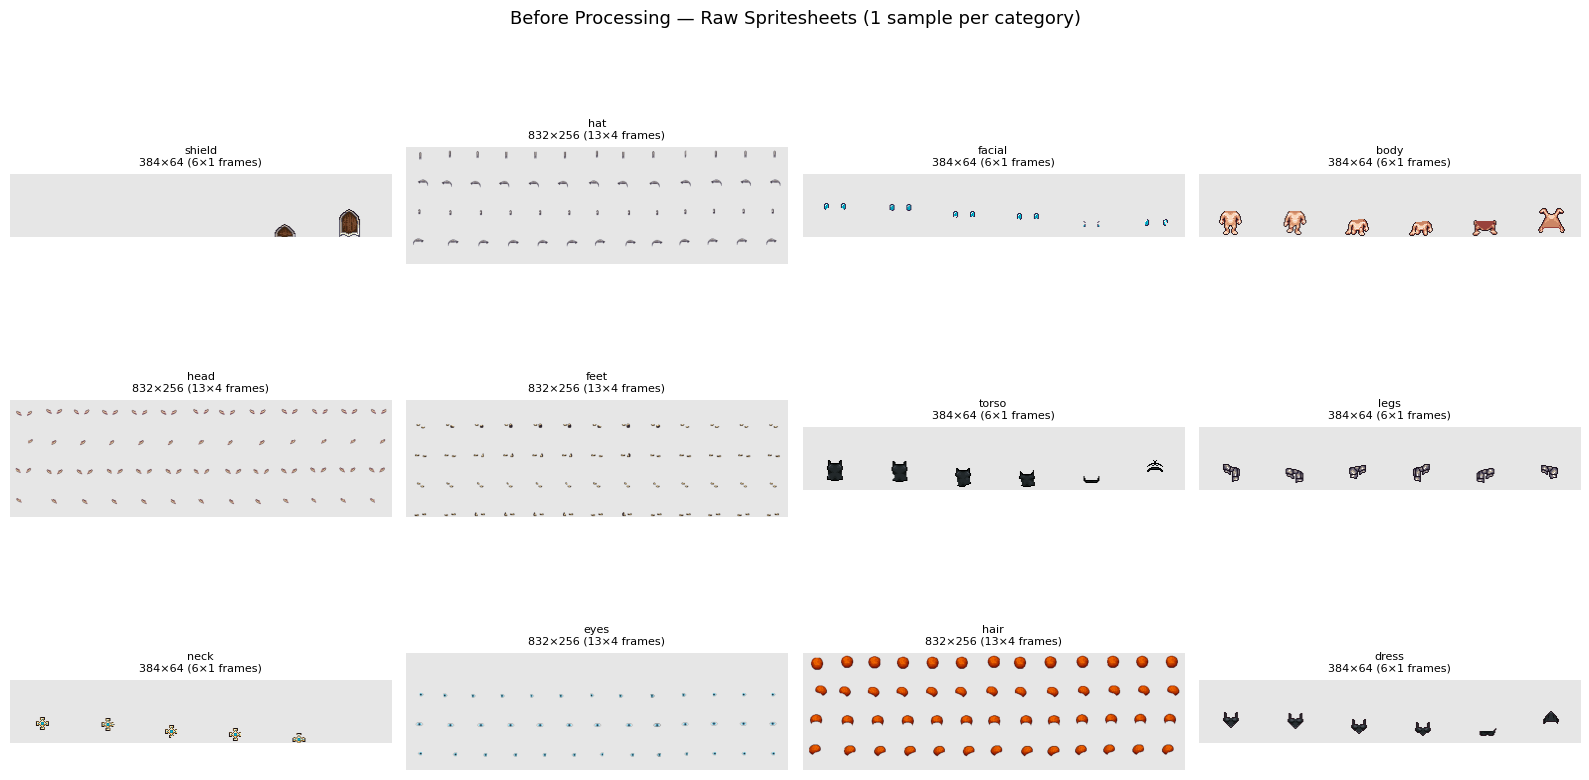

In [23]:
# Pick one representative sheet per category
cat_samples = {}
for p in all_sheets:
    cat = p.relative_to(SPRITESHEETS).parts[0]
    if cat not in cat_samples:
        try:
            img = Image.open(p)
            w, h = img.size
            if w % FRAME_SIZE == 0 and h % FRAME_SIZE == 0:
                cat_samples[cat] = p
        except Exception:
            pass
    if len(cat_samples) == len(cat_sheet_counts):
        break

# Show first 12 categories
show_cats = list(cat_sheet_counts.most_common(12))
ncols, nrows = 4, 3

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 9))
axes = axes.flatten()

for ax, (cat, _) in zip(axes, show_cats):
    path = cat_samples.get(cat)
    if path is None:
        ax.axis('off')
        continue
    img = Image.open(path).convert('RGBA')
    bg = Image.new('RGBA', img.size, (230, 230, 230, 255))
    bg.paste(img, mask=img.split()[3])
    # Downscale for display if very wide
    max_w = 800
    if bg.width > max_w:
        ratio = max_w / bg.width
        bg = bg.resize((max_w, int(bg.height * ratio)), Image.NEAREST)
    ax.imshow(bg)
    w, h = img.size
    ax.set_title(f'{cat}\n{w}×{h} ({w//64}×{h//64} frames)', fontsize=8)
    ax.axis('off')

for ax in axes[len(show_cats):]:
    ax.axis('off')

plt.suptitle('Before Processing — Raw Spritesheets (1 sample per category)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Before — Pixel-Level Analysis (raw sheets)

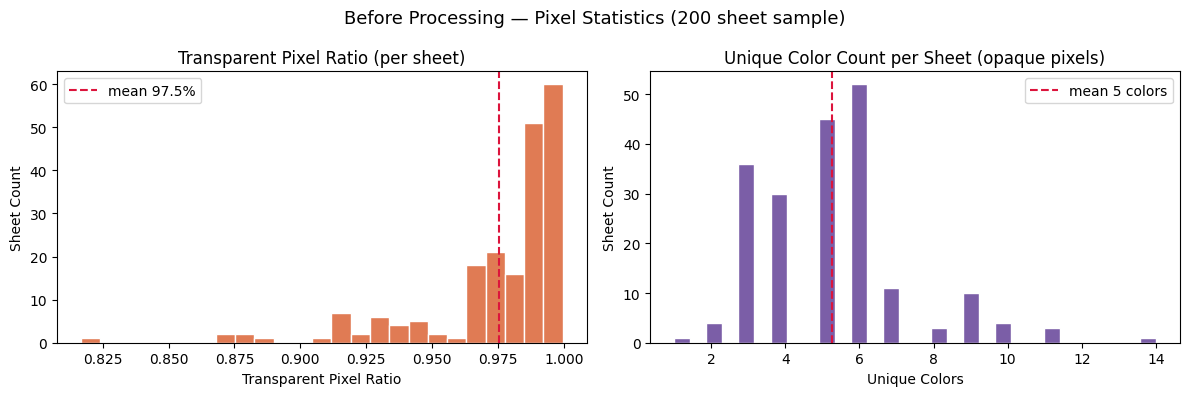

In [24]:
# Sample 200 sheets; measure transparency & unique color count per sheet
import random
random.seed(0)
sample_paths = random.sample(all_sheets, min(200, len(all_sheets)))

sheet_alpha = []
sheet_colors = []
sheet_widths = []
sheet_heights = []

for p in sample_paths:
    try:
        arr = np.array(Image.open(p).convert('RGBA'))
        sheet_alpha.append((arr[:, :, 3] == 0).mean())
        mask = arr[:, :, 3] > 0
        rgb = arr[:, :, :3][mask]
        sheet_colors.append(len(set(map(tuple, rgb.tolist()))) if len(rgb) else 0)
        sheet_widths.append(arr.shape[1])
        sheet_heights.append(arr.shape[0])
    except Exception:
        pass

sheet_alpha  = np.array(sheet_alpha)
sheet_colors = np.array(sheet_colors)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sheet_alpha, bins=25, color='#e07b54', edgecolor='white')
axes[0].axvline(sheet_alpha.mean(), color='crimson', linestyle='--',
                label=f'mean {sheet_alpha.mean():.1%}')
axes[0].set_title('Transparent Pixel Ratio (per sheet)')
axes[0].set_xlabel('Transparent Pixel Ratio')
axes[0].set_ylabel('Sheet Count')
axes[0].legend()

axes[1].hist(sheet_colors, bins=30, color='#7b5ea7', edgecolor='white')
axes[1].axvline(sheet_colors.mean(), color='crimson', linestyle='--',
                label=f'mean {sheet_colors.mean():.0f} colors')
axes[1].set_title('Unique Color Count per Sheet (opaque pixels)')
axes[1].set_xlabel('Unique Colors')
axes[1].set_ylabel('Sheet Count')
axes[1].legend()

plt.suptitle('Before Processing — Pixel Statistics (200 sheet sample)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Preprocessing Logic

In [25]:
def sheet_to_frames(sheet_path: Path):
    """Crop one spritesheet into 64x64 RGBA frames.
    Returns list of (frame_arr, out_path). Fully-transparent frames excluded."""
    try:
        img = Image.open(sheet_path).convert('RGBA')
    except Exception:
        return []

    w, h = img.size
    if w % FRAME_SIZE or h % FRAME_SIZE:
        return []

    cols, rows = w // FRAME_SIZE, h // FRAME_SIZE

    rel   = sheet_path.relative_to(SPRITESHEETS)
    parts = list(rel.parts)          # ['category', ...subdirs..., 'file.png']
    cat   = parts[0]
    stem  = Path(parts[-1]).stem
    dirs  = parts[1:-1]
    base  = '_'.join(dirs + [stem])  # e.g. 'bodies_teen_walk'

    out_dir = PROCESSED / cat
    out_dir.mkdir(parents=True, exist_ok=True)

    arr = np.array(img)
    results = []
    for r in range(rows):
        for c in range(cols):
            y0, y1 = r * FRAME_SIZE, (r + 1) * FRAME_SIZE
            x0, x1 = c * FRAME_SIZE, (c + 1) * FRAME_SIZE
            frame = arr[y0:y1, x0:x1]
            if frame[:, :, 3].max() == 0:   # skip fully transparent
                continue
            results.append((frame, out_dir / f'{base}_{r}_{c}.png'))
    return results


def process_sheet(sheet_path: Path):
    saved = skipped = 0
    for frame_arr, out_path in sheet_to_frames(sheet_path):
        if out_path.exists():
            skipped += 1
        else:
            Image.fromarray(frame_arr, 'RGBA').save(out_path, optimize=False)
            saved += 1
    return saved, skipped

print('sheet_to_frames() and process_sheet() defined.')

sheet_to_frames() and process_sheet() defined.


### 4-a. Step-by-step walkthrough on one sheet

Demo sheet : body/bodies/male/walk.png
Size       : 576×256 px
Grid       : 9 cols × 4 rows  (36 cells)


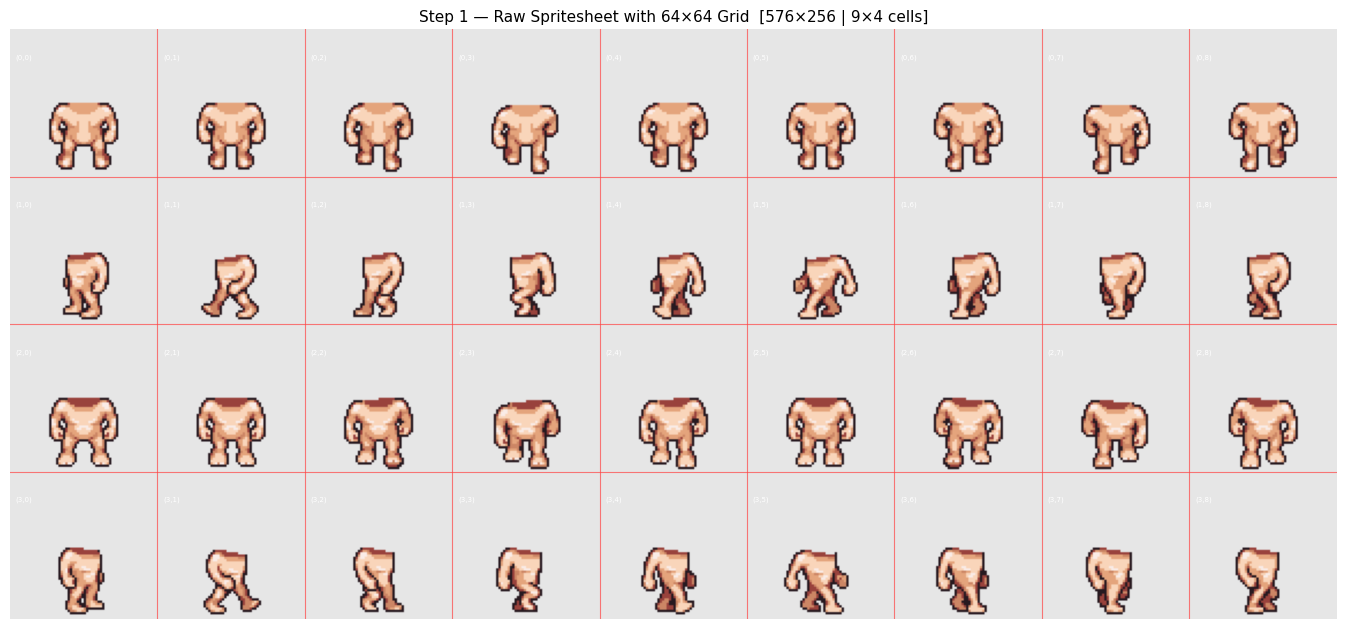

In [26]:
# Pick a body/walk sheet for the walkthrough
demo_candidates = [
    SPRITESHEETS / 'body' / 'bodies' / 'male'     / 'walk.png',
    SPRITESHEETS / 'body' / 'bodies' / 'teen'     / 'walk.png',
    SPRITESHEETS / 'body' / 'bodies' / 'muscular' / 'walk.png',
]
demo_path = next((p for p in demo_candidates if p.exists()), None)
if demo_path is None:
    demo_path = next(SPRITESHEETS.rglob('walk.png'), None)

demo_img = Image.open(demo_path).convert('RGBA')
W, H = demo_img.size
cols, rows = W // FRAME_SIZE, H // FRAME_SIZE

print(f'Demo sheet : {demo_path.relative_to(SPRITESHEETS)}')
print(f'Size       : {W}×{H} px')
print(f'Grid       : {cols} cols × {rows} rows  ({cols*rows} cells)')

# --- Step 1: show raw sheet with grid overlay ---
bg = Image.new('RGBA', demo_img.size, (230, 230, 230, 255))
bg.paste(demo_img, mask=demo_img.split()[3])

fig, ax = plt.subplots(figsize=(max(10, W / 40), max(3, H / 40)))
ax.imshow(bg)
for c in range(1, cols):
    ax.axvline(c * FRAME_SIZE - 0.5, color='#ff4444', linewidth=0.8, alpha=0.7)
for r in range(1, rows):
    ax.axhline(r * FRAME_SIZE - 0.5, color='#ff4444', linewidth=0.8, alpha=0.7)
for r in range(rows):
    for c in range(cols):
        ax.text(c * FRAME_SIZE + 2, r * FRAME_SIZE + 10,
                f'({r},{c})', color='white', fontsize=5, va='top')
ax.set_title(f'Step 1 — Raw Spritesheet with 64×64 Grid  [{W}×{H} | {cols}×{rows} cells]', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

Total cells    : 36
Fully transparent (discarded): 0
Valid frames   : 36


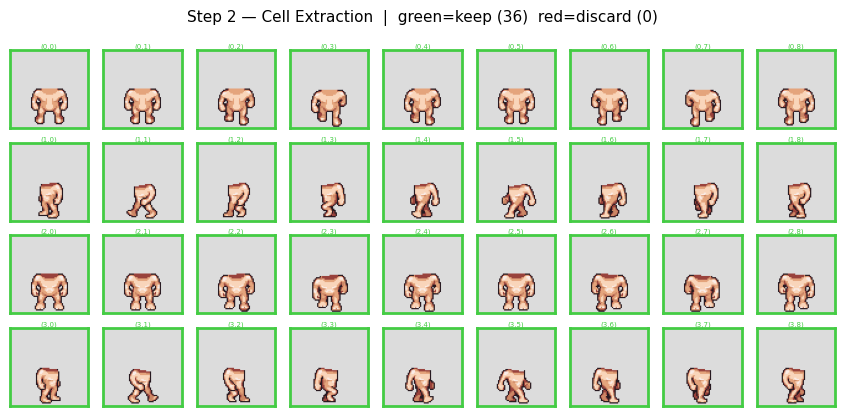

In [27]:
# --- Step 2: extract all cells (incl. transparent) and mark transparent ones ---
arr = np.array(demo_img)
all_cells = []
for r in range(rows):
    for c in range(cols):
        cell = arr[r*FRAME_SIZE:(r+1)*FRAME_SIZE, c*FRAME_SIZE:(c+1)*FRAME_SIZE]
        is_empty = cell[:, :, 3].max() == 0
        all_cells.append((cell, is_empty, r, c))

n_total  = len(all_cells)
n_empty  = sum(1 for _, e, _, _ in all_cells if e)
n_valid  = n_total - n_empty
print(f'Total cells    : {n_total}')
print(f'Fully transparent (discarded): {n_empty}')
print(f'Valid frames   : {n_valid}')

# Visualise all cells — red border = discarded, green = kept
fig, axes = plt.subplots(rows, cols, figsize=(cols * 0.95, rows * 1.05))
axes = np.array(axes).reshape(rows, cols)

for cell, is_empty, r, c in all_cells:
    ax = axes[r][c]
    bg_c = Image.new('RGBA', (FRAME_SIZE, FRAME_SIZE), (220, 220, 220, 255))
    bg_c.paste(Image.fromarray(cell, 'RGBA'), mask=Image.fromarray(cell[:, :, 3], 'L'))
    ax.imshow(bg_c)
    color = '#ff4444' if is_empty else '#44cc44'
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])
    lbl = 'skip' if is_empty else f'({r},{c})'
    ax.set_title(lbl, fontsize=5, color=color, pad=1)

fig.suptitle(
    f'Step 2 — Cell Extraction  |  green=keep ({n_valid})  red=discard ({n_empty})',
    fontsize=11
)
plt.tight_layout()
plt.show()

## 5. Run Preprocessing (skip if already done)

In [28]:
from concurrent.futures import ThreadPoolExecutor, as_completed

t0 = time.time()
total_saved = total_skipped = done = 0
log_every = max(1, len(all_sheets) // 100)

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {executor.submit(process_sheet, p): p for p in all_sheets}
    for fut in as_completed(futures):
        saved, skipped = fut.result()
        total_saved   += saved
        total_skipped += skipped
        done          += 1
        if done % log_every == 0 or done == len(all_sheets):
            elapsed = time.time() - t0
            pct     = done / len(all_sheets) * 100
            rate    = done / elapsed if elapsed else 0
            eta     = (len(all_sheets) - done) / rate if rate else 0
            print(f'  {pct:5.1f}%  [{done:>7,}/{len(all_sheets):,}]  '
                  f'saved={total_saved:>9,}  skipped={total_skipped:>8,}  '
                  f'elapsed={elapsed/60:.1f}m  ETA={eta/60:.1f}m',
                  flush=True)

elapsed = time.time() - t0
print(f'\nDone in {elapsed/60:.1f} min — saved={total_saved:,}  skipped={total_skipped:,}')

    1.0%  [  1,446/144,699]  saved=    2,211  skipped=  31,188  elapsed=0.1m  ETA=6.6m
    2.0%  [  2,892/144,699]  saved=   21,304  skipped=  31,188  elapsed=0.2m  ETA=7.5m
    3.0%  [  4,338/144,699]  saved=   37,365  skipped=  31,188  elapsed=0.2m  ETA=7.6m
    4.0%  [  5,784/144,699]  saved=   56,551  skipped=  31,188  elapsed=0.3m  ETA=8.2m
    5.0%  [  7,230/144,699]  saved=   72,420  skipped=  31,188  elapsed=0.4m  ETA=8.0m
    6.0%  [  8,676/144,699]  saved=   91,727  skipped=  31,188  elapsed=0.5m  ETA=8.1m
    7.0%  [ 10,122/144,699]  saved=  112,733  skipped=  31,188  elapsed=0.6m  ETA=8.3m
    8.0%  [ 11,568/144,699]  saved=  136,338  skipped=  31,188  elapsed=0.7m  ETA=8.5m
    9.0%  [ 13,014/144,699]  saved=  161,858  skipped=  31,188  elapsed=0.9m  ETA=8.7m
   10.0%  [ 14,460/144,699]  saved=  181,207  skipped=  31,188  elapsed=1.0m  ETA=8.6m
   11.0%  [ 15,906/144,699]  saved=  197,343  skipped=  40,344  elapsed=1.0m  ETA=8.4m
   12.0%  [ 17,352/144,699]  saved=  197,34

---
## 6. After — Processed Frame Overview

In [29]:
# Count processed frames per category
cat_frame_counts = Counter()
for p in PROCESSED.rglob('*.png'):
    cat_frame_counts[p.relative_to(PROCESSED).parts[0]] += 1

total_frames = sum(cat_frame_counts.values())
print(f'Total processed frames : {total_frames:,}')
print(f'Categories             : {len(cat_frame_counts)}')
print()
for cat, cnt in cat_frame_counts.most_common():
    pct = cnt / total_frames * 100
    print(f'  {cat:<12s}  {cnt:>9,}  ({pct:4.1f}%)')

Total processed frames : 3,046,247
Categories             : 26

  hat             503,299  (16.5%)
  facial          351,280  (11.5%)
  feet            301,302  ( 9.9%)
  torso           295,414  ( 9.7%)
  head            280,548  ( 9.2%)
  shield          277,111  ( 9.1%)
  legs            242,177  ( 8.0%)
  body            199,615  ( 6.6%)
  neck            150,356  ( 4.9%)
  wings           100,264  ( 3.3%)
  tail             93,593  ( 3.1%)
  hair             67,894  ( 2.2%)
  eyes             56,794  ( 1.9%)
  dress            52,411  ( 1.7%)
  weapon           33,543  ( 1.1%)
  backpack         22,880  ( 0.8%)
  shoulders         5,972  ( 0.2%)
  beards            3,716  ( 0.1%)
  arms              2,956  ( 0.1%)
  wound             2,528  ( 0.1%)
  cape                842  ( 0.0%)
  tools               758  ( 0.0%)
  prosthesis          532  ( 0.0%)
  shadow              214  ( 0.0%)
  quiver              178  ( 0.0%)
  wheelchair           70  ( 0.0%)


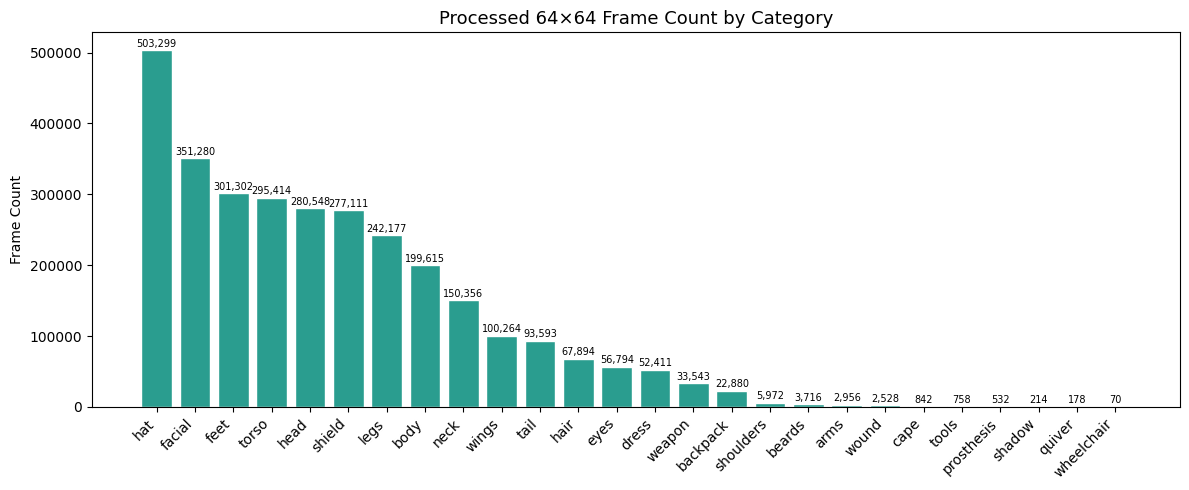

In [30]:
# --- Figure: processed frames per category ---
cats_f, cnts_f = zip(*cat_frame_counts.most_common())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cats_f, cnts_f, color='#2a9d8f', edgecolor='white')
ax.set_title('Processed 64×64 Frame Count by Category', fontsize=13)
ax.set_ylabel('Frame Count')
ax.set_xticks(range(len(cats_f)))
ax.set_xticklabels(cats_f, rotation=45, ha='right')
for bar, v in zip(bars, cnts_f):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{v:,}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## 7. After — Processed Frame Samples

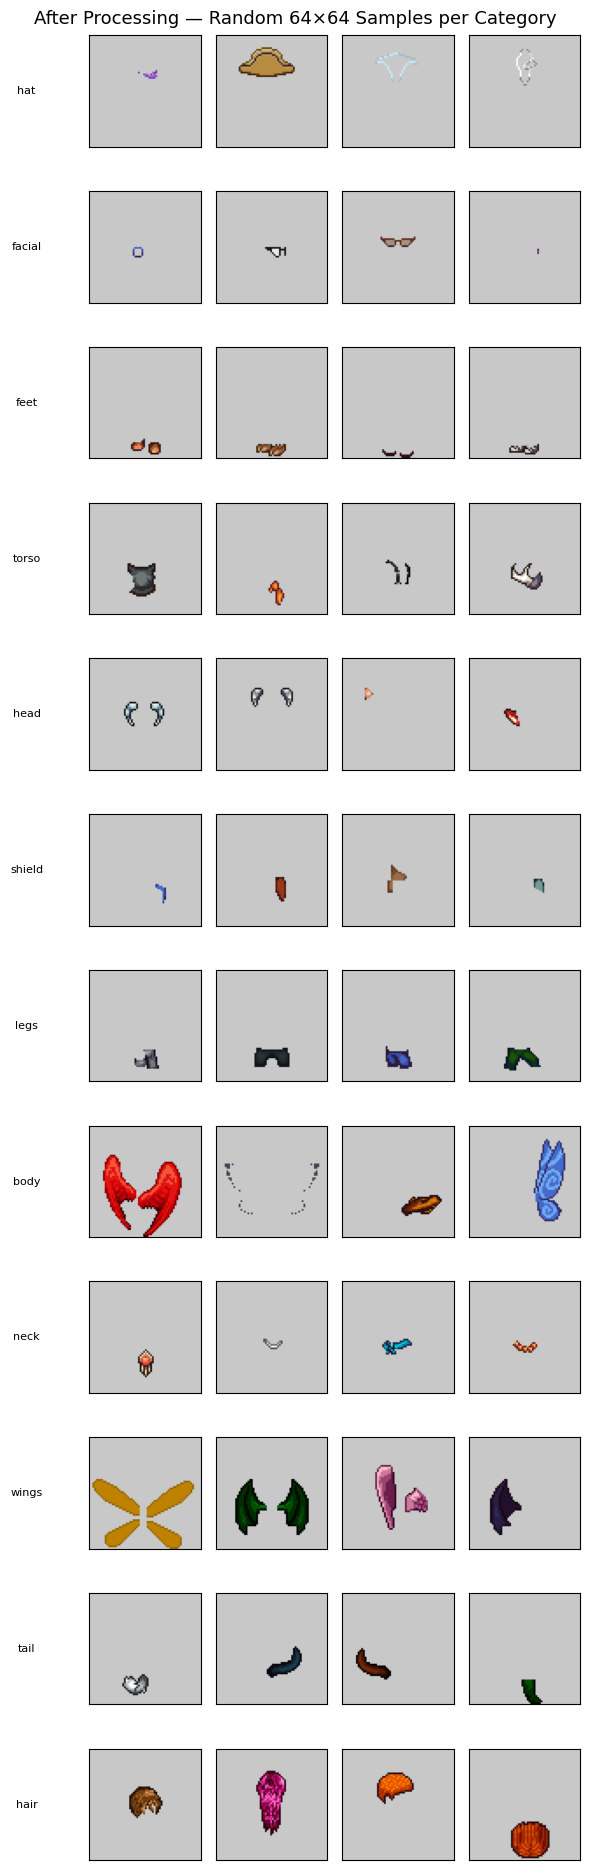

In [31]:
import random
random.seed(42)

# 4 frames per category (top 12)
top_cats = [c for c, _ in cat_frame_counts.most_common(12)]
frames_per_cat = 4
nrows = len(top_cats)
ncols = frames_per_cat

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.6))

for ri, cat in enumerate(top_cats):
    cat_files = list((PROCESSED / cat).glob('*.png'))
    picks = random.sample(cat_files, min(ncols, len(cat_files)))
    for ci in range(ncols):
        ax = axes[ri][ci]
        if ci < len(picks):
            img = Image.open(picks[ci])
            bg = Image.new('RGBA', img.size, (200, 200, 200, 255))
            bg.paste(img, mask=img.split()[3])
            ax.imshow(bg)
        else:
            ax.axis('off')
        if ci == 0:
            ax.set_ylabel(cat, fontsize=8, rotation=0, labelpad=45, va='center')
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('After Processing — Random 64×64 Samples per Category', fontsize=13)
plt.tight_layout()
plt.show()

## 8. After — Pixel-Level Analysis (processed frames)

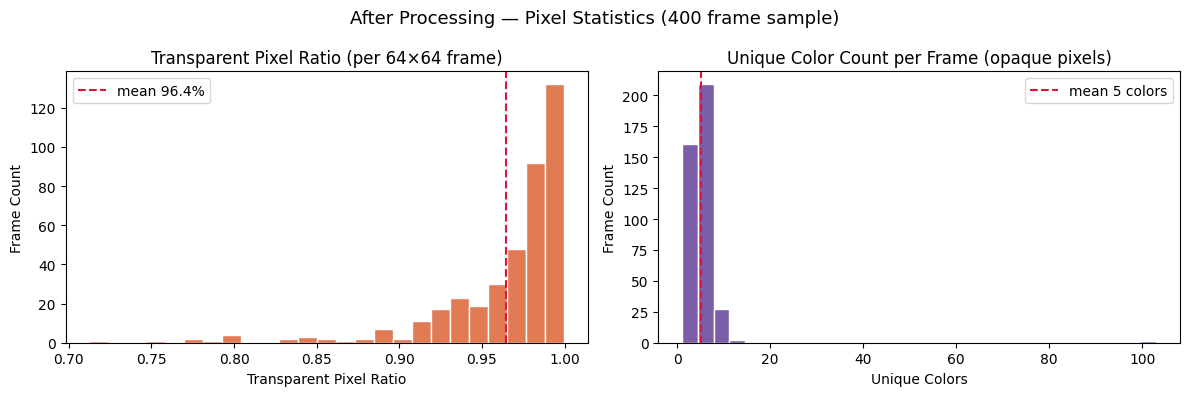

In [32]:
# Sample 400 processed frames
all_proc = list(PROCESSED.rglob('*.png'))
proc_sample = random.sample(all_proc, min(400, len(all_proc)))

proc_alpha  = []
proc_colors = []

for p in proc_sample:
    arr = np.array(Image.open(p))
    proc_alpha.append((arr[:, :, 3] == 0).mean())
    mask = arr[:, :, 3] > 0
    rgb  = arr[:, :, :3][mask]
    proc_colors.append(len(set(map(tuple, rgb.tolist()))) if len(rgb) else 0)

proc_alpha  = np.array(proc_alpha)
proc_colors = np.array(proc_colors)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(proc_alpha, bins=25, color='#e07b54', edgecolor='white')
axes[0].axvline(proc_alpha.mean(), color='crimson', linestyle='--',
                label=f'mean {proc_alpha.mean():.1%}')
axes[0].set_title('Transparent Pixel Ratio (per 64×64 frame)')
axes[0].set_xlabel('Transparent Pixel Ratio')
axes[0].set_ylabel('Frame Count')
axes[0].legend()

axes[1].hist(proc_colors, bins=30, color='#7b5ea7', edgecolor='white')
axes[1].axvline(proc_colors.mean(), color='crimson', linestyle='--',
                label=f'mean {proc_colors.mean():.0f} colors')
axes[1].set_title('Unique Color Count per Frame (opaque pixels)')
axes[1].set_xlabel('Unique Colors')
axes[1].set_ylabel('Frame Count')
axes[1].legend()

plt.suptitle('After Processing — Pixel Statistics (400 frame sample)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Before vs After — Side-by-Side Comparison

/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_49135/3690848769.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


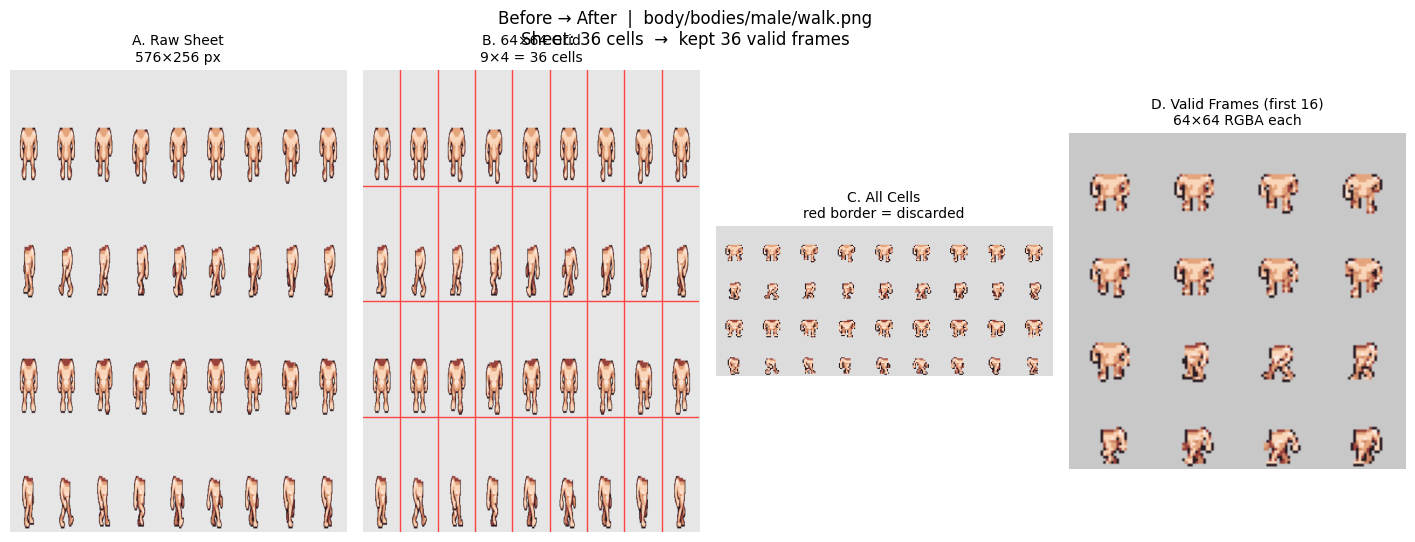

In [33]:
# Panel: raw sheet → grid overlay → extracted frames → discard transparent
demo_frames = sheet_to_frames(demo_path)  # (arr, out_path)
valid_arrs  = [arr for arr, _ in demo_frames]

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

# --- Panel A: raw sheet ---
ax_a = fig.add_subplot(gs[0])
raw_bg = Image.new('RGBA', demo_img.size, (230, 230, 230, 255))
raw_bg.paste(demo_img, mask=demo_img.split()[3])
ax_a.imshow(raw_bg, aspect='auto')
ax_a.set_title(f'A. Raw Sheet\n{demo_img.size[0]}×{demo_img.size[1]} px', fontsize=10)
ax_a.axis('off')

# --- Panel B: grid overlay ---
ax_b = fig.add_subplot(gs[1])
ax_b.imshow(raw_bg, aspect='auto')
for c in range(1, cols):
    ax_b.axvline(c * FRAME_SIZE - 0.5, color='#ff4444', linewidth=1)
for r in range(1, rows):
    ax_b.axhline(r * FRAME_SIZE - 0.5, color='#ff4444', linewidth=1)
ax_b.set_title(f'B. 64×64 Grid\n{cols}×{rows} = {cols*rows} cells', fontsize=10)
ax_b.axis('off')

# --- Panel C: all extracted cells (mini grid) ---
ax_c = fig.add_subplot(gs[2])
thumb_size = 32
canvas_w = cols * thumb_size
canvas_h = rows * thumb_size
canvas = np.full((canvas_h, canvas_w, 3), 220, dtype=np.uint8)
arr2 = np.array(demo_img)
for r2 in range(rows):
    for c2 in range(cols):
        cell = arr2[r2*FRAME_SIZE:(r2+1)*FRAME_SIZE, c2*FRAME_SIZE:(c2+1)*FRAME_SIZE]
        is_empty = cell[:, :, 3].max() == 0
        thumb = Image.fromarray(cell, 'RGBA').resize((thumb_size, thumb_size), Image.NEAREST)
        bg_t  = Image.new('RGBA', (thumb_size, thumb_size), (220, 220, 220, 255))
        bg_t.paste(thumb, mask=thumb.split()[3])
        rgb_t = np.array(bg_t.convert('RGB'))
        if is_empty:
            rgb_t[:4,  :, :] = [255, 80, 80]
            rgb_t[-4:, :, :] = [255, 80, 80]
            rgb_t[:, :4,  :] = [255, 80, 80]
            rgb_t[:, -4:, :] = [255, 80, 80]
        canvas[r2*thumb_size:(r2+1)*thumb_size,
               c2*thumb_size:(c2+1)*thumb_size] = rgb_t
ax_c.imshow(canvas)
ax_c.set_title(f'C. All Cells\nred border = discarded', fontsize=10)
ax_c.axis('off')

# --- Panel D: valid frames only (first 16) ---
ax_d = fig.add_subplot(gs[3])
show_n  = min(16, len(valid_arrs))
grid_c  = 4
grid_r  = (show_n + grid_c - 1) // grid_c
canvas2 = np.full((grid_r * thumb_size, grid_c * thumb_size, 3), 200, dtype=np.uint8)
for i, va in enumerate(valid_arrs[:show_n]):
    r3, c3 = divmod(i, grid_c)
    thumb  = Image.fromarray(va, 'RGBA').resize((thumb_size, thumb_size), Image.NEAREST)
    bg_t   = Image.new('RGBA', (thumb_size, thumb_size), (200, 200, 200, 255))
    bg_t.paste(thumb, mask=thumb.split()[3])
    canvas2[r3*thumb_size:(r3+1)*thumb_size,
            c3*thumb_size:(c3+1)*thumb_size] = np.array(bg_t.convert('RGB'))
ax_d.imshow(canvas2)
ax_d.set_title(f'D. Valid Frames (first {show_n})\n64×64 RGBA each', fontsize=10)
ax_d.axis('off')

plt.suptitle(
    f'Before → After  |  {demo_path.relative_to(SPRITESHEETS)}\n'
    f'Sheet: {cols*rows} cells  →  kept {len(valid_arrs)} valid frames',
    fontsize=12
)
plt.tight_layout()
plt.show()

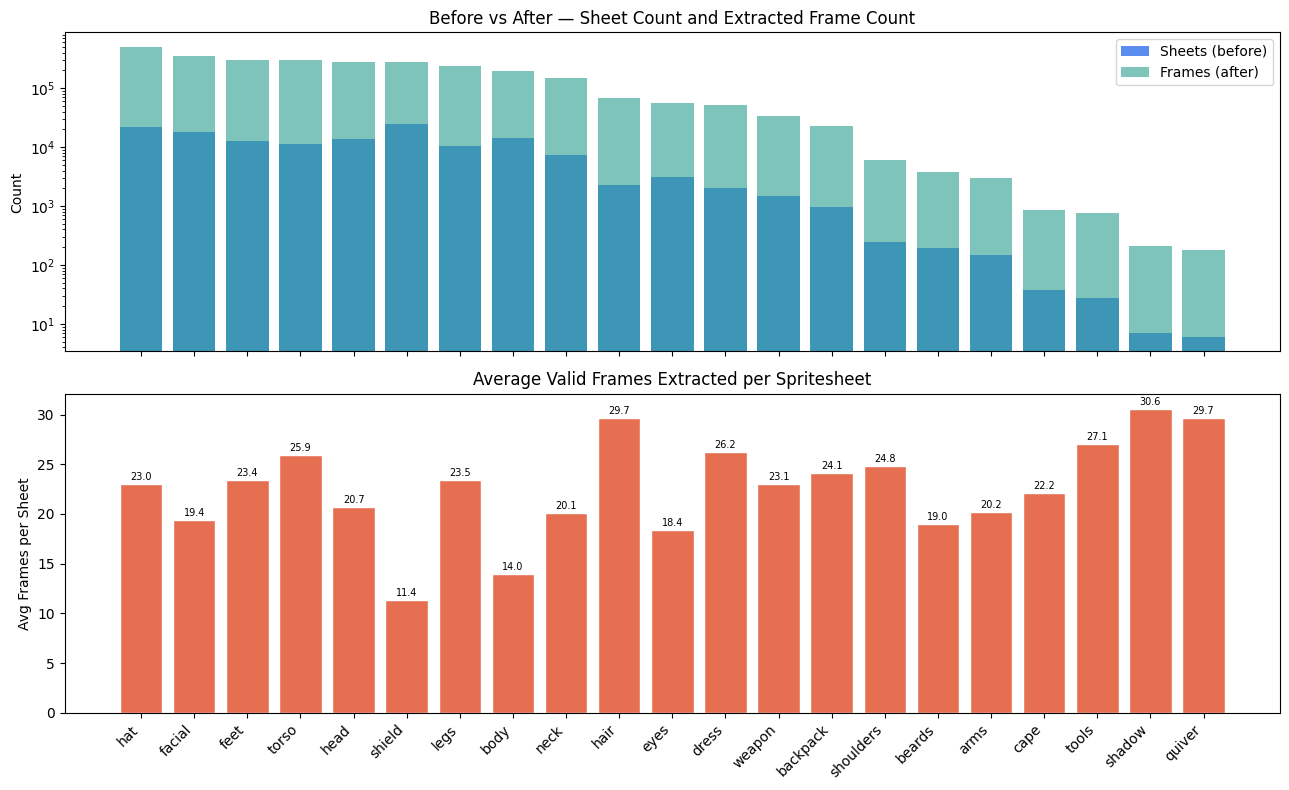

In [34]:
# --- Stacked bar: sheets vs frames per category ---
shared_cats = [c for c in cats_f if c in cat_sheet_counts]
sheet_vals  = [cat_sheet_counts[c] for c in shared_cats]
frame_vals  = [cat_frame_counts[c] for c in shared_cats]
avg_frames  = [f / s for f, s in zip(frame_vals, sheet_vals)]

x = range(len(shared_cats))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.bar(x, sheet_vals, color='#5b8dee', label='Sheets (before)')
ax1.bar(x, frame_vals, color='#2a9d8f', alpha=0.6, label='Frames (after)')
ax1.set_ylabel('Count')
ax1.set_title('Before vs After — Sheet Count and Extracted Frame Count')
ax1.legend()
ax1.set_yscale('log')

ax2.bar(x, avg_frames, color='#e76f51', edgecolor='white')
ax2.set_ylabel('Avg Frames per Sheet')
ax2.set_title('Average Valid Frames Extracted per Spritesheet')
ax2.set_xticks(list(x))
ax2.set_xticklabels(shared_cats, rotation=45, ha='right')
for i, v in enumerate(avg_frames):
    ax2.text(i, v + 0.2, f'{v:.1f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

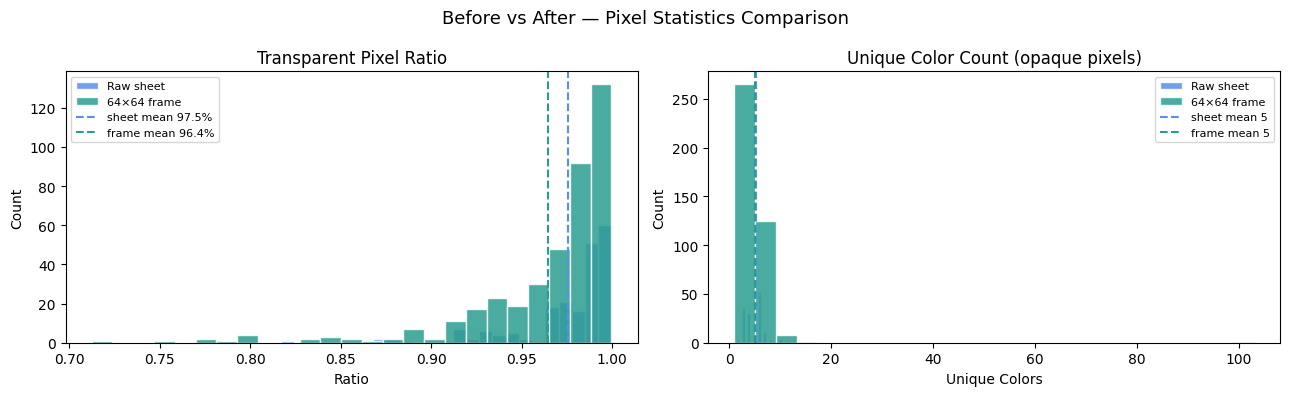

In [35]:
# --- Transparent pixel ratio: sheet vs frame side-by-side histogram ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

kw = dict(bins=25, edgecolor='white', alpha=0.85)
axes[0].hist(sheet_alpha,  color='#5b8dee', label='Raw sheet', **kw)
axes[0].hist(proc_alpha,   color='#2a9d8f', label='64×64 frame', **kw)
axes[0].axvline(sheet_alpha.mean(), color='#5b8dee', linestyle='--', linewidth=1.5,
                label=f'sheet mean {sheet_alpha.mean():.1%}')
axes[0].axvline(proc_alpha.mean(),  color='#2a9d8f',  linestyle='--', linewidth=1.5,
                label=f'frame mean {proc_alpha.mean():.1%}')
axes[0].set_title('Transparent Pixel Ratio')
axes[0].set_xlabel('Ratio')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].hist(sheet_colors, color='#5b8dee', label='Raw sheet', **kw)
axes[1].hist(proc_colors,  color='#2a9d8f', label='64×64 frame', **kw)
axes[1].axvline(sheet_colors.mean(), color='#5b8dee', linestyle='--', linewidth=1.5,
                label=f'sheet mean {sheet_colors.mean():.0f}')
axes[1].axvline(proc_colors.mean(),  color='#2a9d8f',  linestyle='--', linewidth=1.5,
                label=f'frame mean {proc_colors.mean():.0f}')
axes[1].set_title('Unique Color Count (opaque pixels)')
axes[1].set_xlabel('Unique Colors')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.suptitle('Before vs After — Pixel Statistics Comparison', fontsize=13)
plt.tight_layout()
plt.show()

---
## 10. Summary

In [36]:
rows_summary = [
    ('Total spritesheet files',   f'{total_sheets:,}',        '—'),
    ('Total processed frames',    '—',                        f'{total_frames:,}'),
    ('Avg frames per sheet',      '—',                        f'{total_frames/total_sheets:.1f}'),
    ('Frame size',                'various',                  '64×64 px (fixed)'),
    ('Channels',                  'P / RGBA',                 'RGBA (4ch)'),
    ('Transparent pixel ratio',   f'{sheet_alpha.mean():.1%}', f'{proc_alpha.mean():.1%}'),
    ('Avg unique colors',         f'{sheet_colors.mean():.0f}', f'{proc_colors.mean():.0f}'),
    ('Fully-transparent frames',  '—',                        'discarded'),
    ('Value range',               '—',                        '[0, 255]  →  [0.0, 1.0] after /255'),
]

col_w = [32, 22, 28]
header = f'{"Metric":<{col_w[0]}} {"Before":>{col_w[1]}} {"After":>{col_w[2]}}'
sep    = '-' * sum(col_w)
print(sep)
print(header)
print(sep)
for metric, before, after in rows_summary:
    print(f'{metric:<{col_w[0]}} {before:>{col_w[1]}} {after:>{col_w[2]}}')
print(sep)

----------------------------------------------------------------------------------
Metric                                           Before                        After
----------------------------------------------------------------------------------
Total spritesheet files                         144,699                            —
Total processed frames                                —                    3,046,247
Avg frames per sheet                                  —                         21.1
Frame size                                      various             64×64 px (fixed)
Channels                                       P / RGBA                   RGBA (4ch)
Transparent pixel ratio                           97.5%                        96.4%
Avg unique colors                                     5                            5
Fully-transparent frames                              —                    discarded
Value range                                           — [0, 255]  →  